Saving archive.zip to archive (3).zip


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


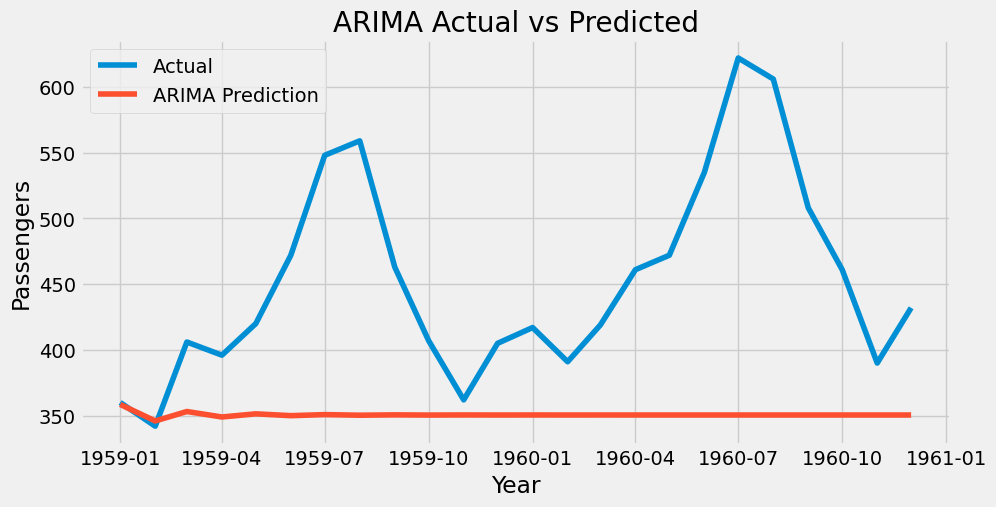

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


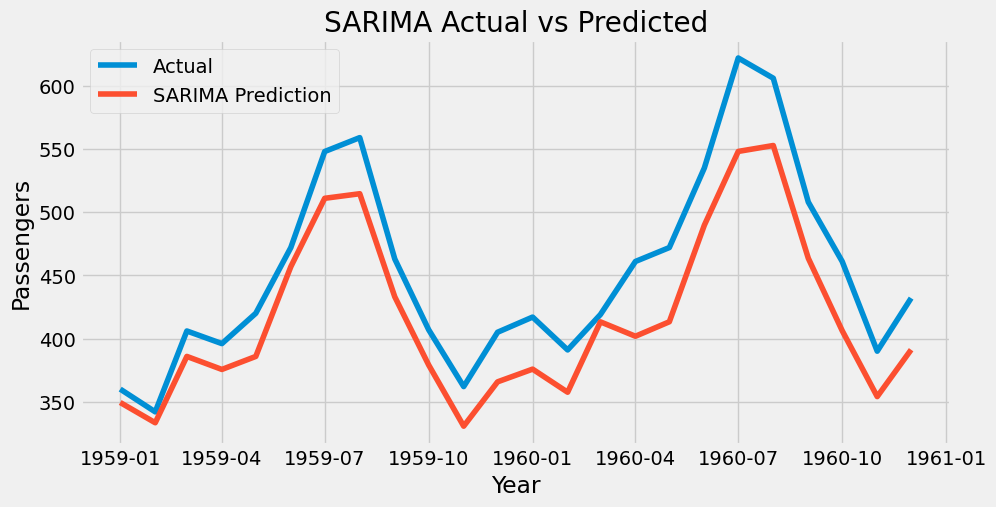

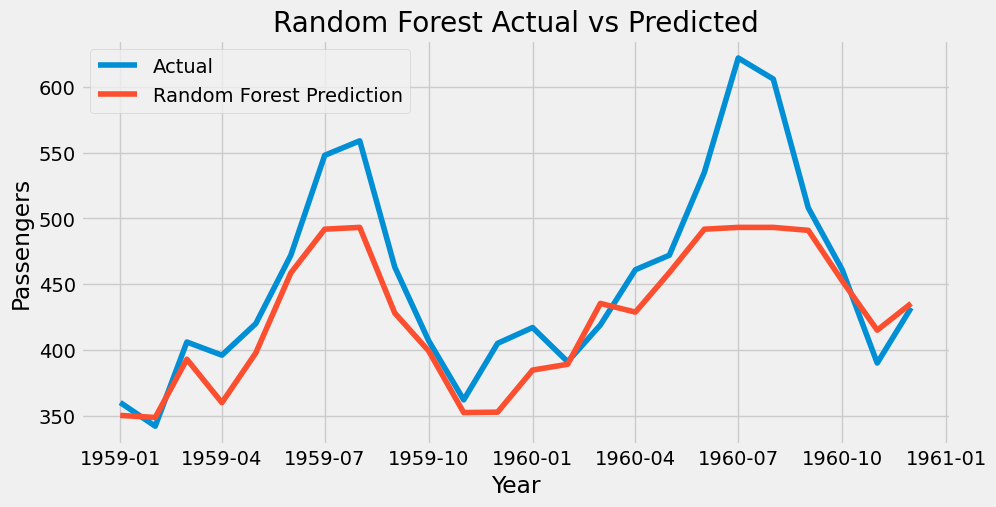

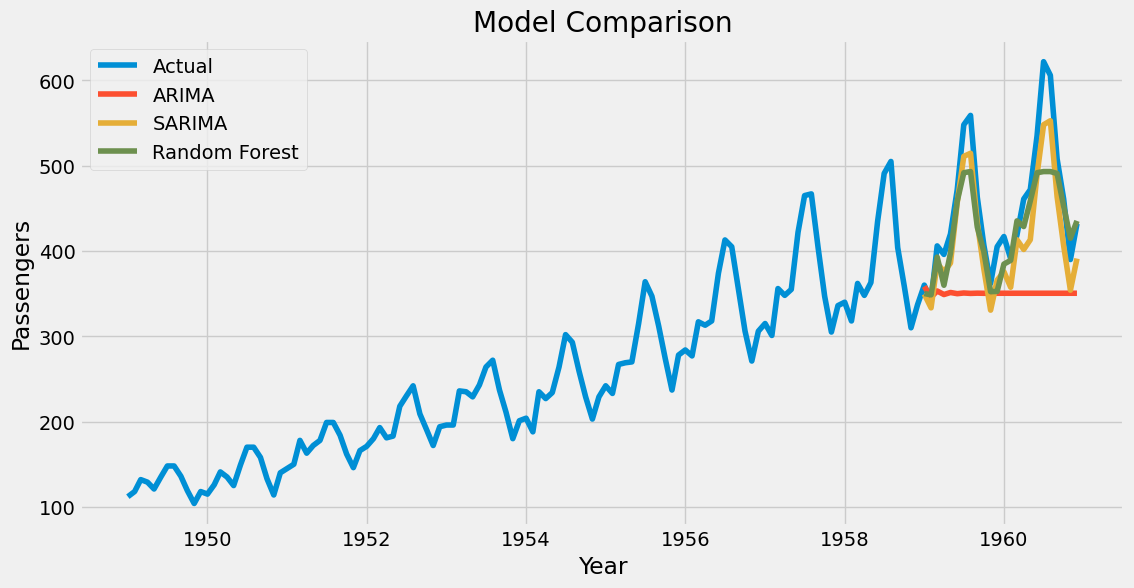

ARIMA RMSE: 126.15
SARIMA RMSE: 39.81
Random Forest RMSE: 45.01


In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

uploaded = files.upload()
file_path = list(uploaded.keys())[0]

data = pd.read_csv(file_path, parse_dates=[0], index_col=0)
ts = data.iloc[:, 0]

ts_log = np.log(ts)

train = ts_log[: "1958-12-01"]
test = ts_log["1959-01-01":]
actual_test = np.exp(test)

arima_fit = ARIMA(train, order=(1,1,1)).fit()
arima_pred = np.exp(arima_fit.forecast(len(test)))

plt.figure(figsize=(10,5))
plt.plot(actual_test, label="Actual")
plt.plot(test.index, arima_pred, label="ARIMA Prediction")
plt.title("ARIMA Actual vs Predicted")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.legend()
plt.show()

sarima_fit = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12)).fit(disp=False)
sarima_pred = np.exp(sarima_fit.forecast(len(test)))

plt.figure(figsize=(10,5))
plt.plot(actual_test, label="Actual")
plt.plot(test.index, sarima_pred, label="SARIMA Prediction")
plt.title("SARIMA Actual vs Predicted")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.legend()
plt.show()

df = pd.DataFrame(ts)
df["lag1"] = df.iloc[:,0].shift(1)
df["lag12"] = df.iloc[:,0].shift(12)
df.dropna(inplace=True)

train_ml = df[: "1958-12-01"]
test_ml = df["1959-01-01":]

X_train = train_ml[["lag1","lag12"]]
y_train = train_ml.iloc[:,0]
X_test = test_ml[["lag1","lag12"]]
y_test = test_ml.iloc[:,0]

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

plt.figure(figsize=(10,5))
plt.plot(y_test, label="Actual")
plt.plot(test_ml.index, rf_pred, label="Random Forest Prediction")
plt.title("Random Forest Actual vs Predicted")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.legend()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(ts, label="Actual")
plt.plot(test.index, arima_pred, label="ARIMA")
plt.plot(test.index, sarima_pred, label="SARIMA")
plt.plot(test_ml.index, rf_pred, label="Random Forest")
plt.title("Model Comparison")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.legend()
plt.show()

print("ARIMA RMSE:", round(np.sqrt(mean_squared_error(actual_test, arima_pred)),2))
print("SARIMA RMSE:", round(np.sqrt(mean_squared_error(actual_test, sarima_pred)),2))
print("Random Forest RMSE:", round(np.sqrt(mean_squared_error(y_test, rf_pred)),2))


Saving archive.zip to archive.zip


<Figure size 1000x400 with 0 Axes>

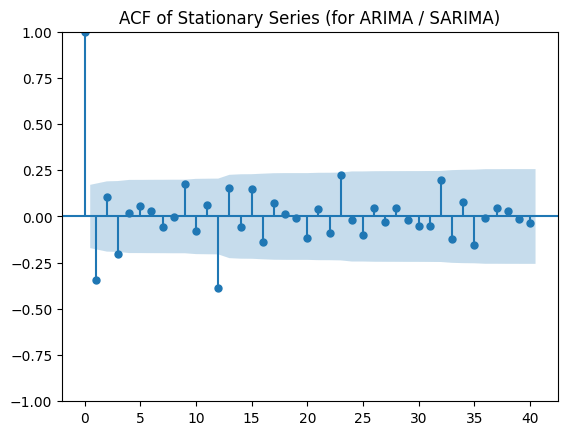

<Figure size 1000x400 with 0 Axes>

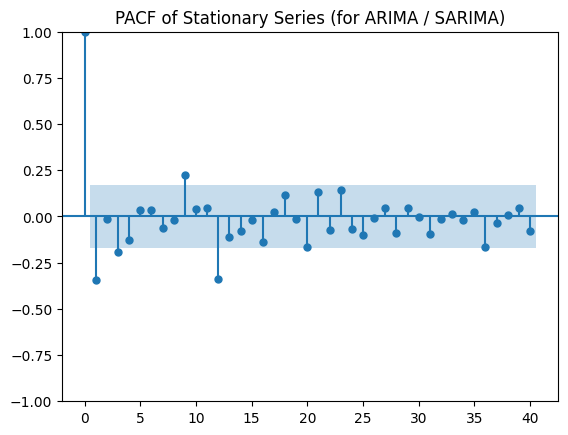

In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

uploaded = files.upload()
file_path = list(uploaded.keys())[0]

data = pd.read_csv(file_path, parse_dates=[0], index_col=0)
ts = data.iloc[:, 0]

ts_log = np.log(ts)

stationary_series = ts_log.diff().diff(12).dropna()

plt.figure(figsize=(10,4))
plot_acf(stationary_series, lags=40)
plt.title("ACF of Stationary Series (for ARIMA / SARIMA)")
plt.show()

plt.figure(figsize=(10,4))
plot_pacf(stationary_series, lags=40)
plt.title("PACF of Stationary Series (for ARIMA / SARIMA)")
plt.show()
